# 02. Approche 1, le modèle sur mesure simple

Projet Air Paradis, prédiction du sentiment d'un tweet.

## Ce que je fais dans ce notebook

Je construis la référence de base du projet : un modèle classique, rapide à
entraîner, sans réseau de neurones.

Son rôle n'est pas de gagner la comparaison. Il est de répondre à une question
qu'on devrait toujours se poser avant d'investir dans des modèles lourds :
jusqu'où est-ce qu'on peut aller avec une méthode simple ?

Si le modèle classique atteint 78 % et que BERT atteint 79 %, la conclusion
pour Air Paradis n'est pas la même que si l'écart était de 20 points. Cette
référence donne son sens à tout le reste du projet, et c'est exactement ce que
Marc demande de démontrer dans son mail.

### L'approche en deux temps

Il y a toujours deux étapes quand on veut classer du texte : d'abord
transformer le texte en nombres, ensuite apprendre à décider à partir de ces
nombres.

| L'étape | La méthode | Ce qu'elle fait |
|---|---|---|
| Transformer le texte en nombres | TF-IDF | Chaque tweet devient une liste de nombres, un par mot du vocabulaire |
| Décider | Régression logistique | Le modèle apprend un poids par mot et combine ces poids pour trancher |

### Sa limite, que je connais d'avance

Cette approche traite le tweet comme un sac de mots : elle compte les mots
présents mais elle ignore complètement leur ordre. Pour elle, "not good" et
"good not" sont la même chose. C'est justement la faiblesse que les approches
2 et 3 vont corriger.

## 1. Préparer l'environnement

In [1]:
import sys
from pathlib import Path

RACINE_PROJET = next(
    dossier
    for dossier in [Path.cwd(), *Path.cwd().parents]
    if (dossier / "pytest.ini").exists()
)

if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

print(f"Racine du projet : {RACINE_PROJET}")

Racine du projet : C:\Users\dwyts\Documents\PROJET7 Openclassrooms


In [2]:
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.models import infer_signature
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from src import config
from src.data_loader import charger_echantillon, formater_nombre, separer_train_test
from src.evaluation import (
    afficher_metriques,
    calculer_metriques,
    tracer_courbe_roc,
    tracer_matrice_confusion,
)
from src.preprocessing import retirer_mots_vides

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

print("Bibliothèques chargées.")

Bibliothèques chargées.


### Se connecter à MLflow

MLflow est l'outil qui garde la trace de chaque entraînement : les réglages
utilisés, les scores obtenus, le temps passé, et le modèle lui-même. Sans lui,
au bout de quinze essais je ne sais plus lequel était le meilleur ni avec
quels réglages je l'avais obtenu.

Le vocabulaire de MLflow tient en trois mots. Une expérience est un dossier de
résultats, j'en fais une par approche. Un run est une exécution enregistrée,
avec ses réglages et ses scores. Le Model Registry est le catalogue des
modèles, qui leur donne un numéro de version.

MLflow doit déjà tourner quand j'exécute cette cellule. Si ce n'est pas le
cas, elle m'affiche la commande à lancer dans un autre terminal.

In [3]:
mlflow.set_tracking_uri(config.URI_SUIVI_MLFLOW)

# Je vérifie tout de suite que le serveur répond, plutôt que de découvrir le
# problème vingt minutes plus tard à la fin d'un entraînement. Cette requête
# est instantanée et sans effet de bord.
try:
    mlflow.search_experiments(max_results=1)
except Exception as erreur:
    raise RuntimeError(
        "\n" + "=" * 70 +
        "\nSERVEUR MLFLOW INJOIGNABLE"
        f"\nAdresse essayee : {config.URI_SUIVI_MLFLOW}"
        "\n\nOuvrez un second terminal a la racine du projet et lancez :"
        "\n"
        "\n  .venv\\Scripts\\python.exe -m mlflow server "
        "--backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000"
        "\n\nPuis reexecutez cette cellule."
        "\n" + "=" * 70
    ) from erreur

mlflow.set_experiment(config.EXPERIENCE_CLASSIQUE)

print(f"MLflow connecté  : {config.URI_SUIVI_MLFLOW}")
print(f"Expérience       : {config.EXPERIENCE_CLASSIQUE}")

MLflow connecté  : http://127.0.0.1:5000
Expérience       : 01_modele_classique


## 2. Charger les données

C'est de loin l'approche la moins coûteuse en calcul, donc je peux me
permettre de lui donner tout le jeu de données, soit un million et demi de
tweets.

C'est un point à garder en tête pour la comparaison finale : les approches 2
et 3 devront, elles, se contenter d'un échantillon. Le modèle classique part
donc avec un avantage, il voit plus de données. Ça rend d'autant plus parlant
l'écart de performance qui restera quand même.

In [4]:
donnees = charger_echantillon(config.TAILLE_ECHANTILLON_CLASSIQUE)
X_train, X_test, y_train, y_test = separer_train_test(donnees, colonne_texte="texte_nettoye")

Jeu de donnees complet : 1 517 518 tweets


Entrainement : 1 214 014 tweets
Test         : 303 504 tweets


## 3. Comment marche TF-IDF

Un modèle ne sait manipuler que des nombres, il faut donc transformer chaque
tweet en une liste de nombres. C'est le rôle de TF-IDF.

TF-IDF veut dire Term Frequency, Inverse Document Frequency, soit fréquence du
terme et fréquence inverse de document. Le principe tient en une phrase : un
mot est important s'il est fréquent dans ce tweet-ci, mais rare dans
l'ensemble des tweets.

La partie TF dit que plus un mot apparaît dans un tweet, plus il compte. La
partie IDF dit l'inverse : plus un mot est présent partout, moins il compte.

C'est l'IDF qui fait tout le travail utile. Le mot "the" apparaît dans presque
tous les tweets, il ne distingue rien, donc son poids s'effondre. Le mot
"terrible" est rare, donc quand il apparaît il est très informatif et son
poids monte.

Pourquoi TF-IDF et pas un simple comptage des mots ? Justement parce qu'un
comptage brut donnerait le plus de poids aux mots les plus fréquents,
c'est-à-dire aux mots qui n'apprennent rien. TF-IDF corrige exactement ce
défaut, et c'est pour ça que c'est la méthode standard depuis des décennies.

Voyons ça sur trois phrases.

In [5]:
# Démonstration sur trois phrases, pour rendre le mécanisme visible.
phrases_demo = [
    "the flight was great",
    "the flight was terrible",
    "great crew great food",
]

vectoriseur_demo = TfidfVectorizer(token_pattern=r"\S+")
matrice_demo = vectoriseur_demo.fit_transform(phrases_demo)

pd.DataFrame(
    matrice_demo.toarray().round(2),
    columns=vectoriseur_demo.get_feature_names_out(),
    index=phrases_demo,
)

,crew,flight,food,great,terrible,the,was
the flight was great,0.00,0.50,0.00,0.50,0.0,0.50,0.50
the flight was terrible,0.00,0.46,0.00,0.00,0.6,0.46,0.46
great crew great food,0.48,0.00,0.48,0.73,0.0,0.00,0.00


Ce que montre le tableau.

Les mots "the" et "flight" apparaissent dans les deux premières phrases, donc
leur poids est faible. Le mot "terrible" n'apparaît qu'une fois dans tout le
corpus, donc son poids est le plus élevé de sa ligne : c'est exactement le
comportement recherché. Et "great" apparaît deux fois dans la troisième
phrase, donc son poids y est renforcé.

On voit aussi la limite de la méthode. Chaque phrase n'est qu'une collection
de mots sans ordre. Rien dans ce tableau ne permettrait de distinguer "not
good" de "good not".

### Un détail technique qui a son importance

Par défaut, scikit-learn découpe le texte en mots avec un motif qui a deux
effets gênants ici. Il coupe sur l'apostrophe, donc "don't" devient "don" plus
"t" et la négation disparaît. Et il jette les mots d'une seule lettre.

Or mon texte est déjà nettoyé et découpé par espaces en amont, dans
`src/preprocessing.py`. Je lui impose donc le motif `\S+`, qui veut dire
"tout groupe de caractères qui ne sont pas des espaces". Les mots obtenus sont
alors exactement ceux que mon prétraitement a préparés, ni plus ni moins.

In [6]:
# Vérification concrète de ce que change ce réglage.
phrase = "i don't like it"

for motif, description in [(r"(?u)\b\w\w+\b", "défaut scikit-learn"), (r"\S+", "mon réglage")]:
    vectoriseur = TfidfVectorizer(token_pattern=motif)
    vectoriseur.fit([phrase])
    print(f"{description:22s} : {list(vectoriseur.get_feature_names_out())}")

défaut scikit-learn    : ['don', 'it', 'like']
mon réglage            : ["don't", 'i', 'it', 'like']


## 4. La référence absolue, répondre au hasard

Avant tout modèle sérieux, je mesure ce que donne une stratégie sans aucune
intelligence : répondre au hasard, en respectant simplement la proportion des
classes. C'est ce que fait le `DummyClassifier` de scikit-learn.

Ce n'est pas une formalité. C'est le plancher en dessous duquel un modèle n'a
aucune valeur, et je l'enregistre dans MLflow comme les autres, pour que la
comparaison finale contienne son point de départ.

In [7]:
with mlflow.start_run(run_name="00_reference_hasard"):
    mlflow.log_params({
        "approche": "reference",
        "modele": "classifieur_naif",
        "strategie": "stratifie",
        "nombre_tweets_entrainement": len(X_train),
    })

    modele_naif = DummyClassifier(strategy="stratified", random_state=config.GRAINE_ALEATOIRE)
    modele_naif.fit(X_train, y_train)

    probabilites_naif = modele_naif.predict_proba(X_test)[:, 1]
    metriques_naif = calculer_metriques(y_test, probabilites_naif)

    mlflow.log_metrics(metriques_naif)

afficher_metriques(metriques_naif, "Reference, reponse au hasard")

🏃 View run 00_reference_hasard at: http://127.0.0.1:5000/#/experiments/1/runs/ff4b4b97b28c481283e50bfd290361d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
REFERENCE, REPONSE AU HASARD
  Exactitude                : 0.4989
  AUC ROC                   : 0.4989
  F1 macro                  : 0.4989
--------------------------------------------------------
  Classe NEGATIVE (les bad buzz a detecter)
    Precision               : 0.5037
    Rappel                  : 0.5026   <-- mesure metier
    F1                      : 0.5032


## 5. Mon plan d'expérimentation

Plutôt que de régler les paramètres à l'intuition, je teste toutes les
combinaisons de deux facteurs à deux niveaux, ce qui fait quatre
configurations.

| Le facteur | Niveau A | Niveau B | La question que je me pose |
|---|---|---|---|
| n-grammes | mots seuls | mots seuls et paires de mots | Est-ce que capturer les paires compense un peu l'absence d'ordre ? |
| mots vides | conservés | retirés | Est-ce qu'alléger le vocabulaire aide, ou est-ce qu'on perd de l'information ? |

Un n-gramme est simplement une suite de n mots consécutifs. Un unigramme est
un mot seul, un bigramme est une paire de mots qui se suivent. Les bigrammes
sont le seul moyen pour un sac de mots d'entrevoir un ordre : "not good"
devient un terme à part entière, distinct de "not" et de "good". C'est un
contournement partiel, il ne marche que pour les mots collés l'un à l'autre,
mais ça vaut le coup de mesurer ce que ça rapporte.

Les quatre essais sont enregistrés dans MLflow. Je choisirai la configuration
sur la mesure, pas sur une préférence.

In [8]:
# Les quatre configurations à tester.
CONFIGURATIONS = [
    {"nom": "01_mots_seuls",                     "ngram_max": 1, "retirer_mots_vides": False},
    {"nom": "02_mots_seuls_sans_mots_vides",     "ngram_max": 1, "retirer_mots_vides": True},
    {"nom": "03_avec_bigrammes",                 "ngram_max": 2, "retirer_mots_vides": False},
    {"nom": "04_avec_bigrammes_sans_mots_vides", "ngram_max": 2, "retirer_mots_vides": True},
]

# Les réglages communs à toutes les configurations. Seuls les deux facteurs
# que j'étudie changent d'un essai à l'autre, tout le reste est identique.

# Le nombre maximum de termes gardés dans le vocabulaire. Ça borne la mémoire
# utilisée et ça écarte la longue traîne des termes vus deux ou trois fois.
MAX_TERMES = 300_000

# Un terme vu une seule fois dans tout le corpus est du bruit, pas du signal.
FREQUENCE_MINIMALE = 2

# La force de régularisation de la régression logistique. La régularisation
# empêche le modèle de donner un poids énorme à un mot qu'il a peu vu, ce qui
# le ferait coller au jeu d'entraînement au lieu de généraliser. La valeur 1.0
# est la valeur par défaut de scikit-learn, c'est un compromis raisonnable.
FORCE_REGULARISATION = 1.0

print(f"{len(CONFIGURATIONS)} configurations à tester.")

4 configurations à tester.


### La boucle d'expérimentation

Chaque tour de boucle ouvre un run MLflow, y enregistre les réglages,
entraîne, mesure, et enregistre les scores. Je garde les modèles entraînés en
mémoire : le meilleur sera analysé en détail puis versé au Model Registry à la
fin du notebook.

Pourquoi je n'enregistre pas les quatre modèles dans MLflow ? Parce que chacun
pèse plusieurs dizaines de mégaoctets, essentiellement à cause du vocabulaire
TF-IDF. Stocker les quatre reviendrait à garder des fichiers lourds dont trois
ne serviront jamais. J'enregistre les réglages et les scores des quatre, c'est
ce qui rend la démarche traçable, et le modèle du seul qui part en production.

In [9]:
resultats = []
modeles_entraines = {}

for configuration in CONFIGURATIONS:
    with mlflow.start_run(run_name=configuration["nom"]):

        # Le prétraitement propre à cette configuration.
        if configuration["retirer_mots_vides"]:
            textes_train = X_train.apply(retirer_mots_vides)
            textes_test = X_test.apply(retirer_mots_vides)
        else:
            textes_train, textes_test = X_train, X_test

        # Les réglages, enregistrés dans MLflow.
        mlflow.log_params({
            "approche": "classique",
            "vectorisation": "tfidf",
            "ngram_max": configuration["ngram_max"],
            "mots_vides_retires": configuration["retirer_mots_vides"],
            "max_termes": MAX_TERMES,
            "frequence_minimale": FREQUENCE_MINIMALE,
            "modele": "regression_logistique",
            "force_regularisation": FORCE_REGULARISATION,
            "nombre_tweets_entrainement": len(X_train),
        })

        # Le pipeline.
        #
        # Un Pipeline scikit-learn enchaîne plusieurs étapes en un seul objet.
        # L'avantage est décisif pour la mise en production : le modèle
        # sauvegardé embarque son propre prétraitement, donc il est impossible
        # de l'utiliser plus tard avec une vectorisation différente de celle
        # qui a servi à l'entraîner.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1, configuration["ngram_max"]),
                max_features=MAX_TERMES,
                min_df=FREQUENCE_MINIMALE,
                token_pattern=r"\S+",
                # sublinear_tf remplace la fréquence brute par 1 + log(f).
                # Autrement dit : un mot répété dix fois est plus important
                # qu'un mot vu une fois, mais pas dix fois plus important.
                sublinear_tf=True,
            )),
            ("classifieur", LogisticRegression(
                C=FORCE_REGULARISATION,
                max_iter=1000,
                random_state=config.GRAINE_ALEATOIRE,
            )),
        ])

        # L'entraînement, chronométré.
        debut = time.perf_counter()
        pipeline.fit(textes_train, y_train)
        duree = time.perf_counter() - debut

        # L'évaluation.
        probabilites = pipeline.predict_proba(textes_test)[:, 1]
        metriques = calculer_metriques(y_test, probabilites)

        mlflow.log_metrics({
            **metriques,
            "duree_entrainement_s": duree,
            "taille_vocabulaire": len(pipeline.named_steps["tfidf"].vocabulary_),
        })

        # Je garde le modèle pour la suite du notebook.
        modeles_entraines[configuration["nom"]] = pipeline
        resultats.append({
            "configuration": configuration["nom"],
            "ngram_max": configuration["ngram_max"],
            "mots_vides_retires": configuration["retirer_mots_vides"],
            "vocabulaire": len(pipeline.named_steps["tfidf"].vocabulary_),
            "duree_s": round(duree, 1),
            **{cle: round(valeur, 4) for cle, valeur in metriques.items()},
        })

        print(f"{configuration['nom']:38s} "
              f"exactitude {metriques['exactitude']:.4f}  "
              f"AUC {metriques['auc_roc']:.4f}  "
              f"({duree:.0f}s)")

print("\nTermine. Resultats consultables dans l'interface MLflow.")

01_mots_seuls                          exactitude 0.7980  AUC 0.8766  (18s)
🏃 View run 01_mots_seuls at: http://127.0.0.1:5000/#/experiments/1/runs/536e74190d234340b699d6c3a1bccf3d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


02_mots_seuls_sans_mots_vides          exactitude 0.7894  AUC 0.8679  (11s)
🏃 View run 02_mots_seuls_sans_mots_vides at: http://127.0.0.1:5000/#/experiments/1/runs/451ab44b0830441780ee135bc5be365f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


03_avec_bigrammes                      exactitude 0.8218  AUC 0.9006  (54s)
🏃 View run 03_avec_bigrammes at: http://127.0.0.1:5000/#/experiments/1/runs/de8a9c71784a4a2c8f1b31632bd4794c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


04_avec_bigrammes_sans_mots_vides      exactitude 0.8076  AUC 0.8865  (41s)
🏃 View run 04_avec_bigrammes_sans_mots_vides at: http://127.0.0.1:5000/#/experiments/1/runs/66ebe7ba687f4c39bae7192d6cfd1739
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Termine. Resultats consultables dans l'interface MLflow.


## 6. Comparer les quatre configurations

In [10]:
tableau = pd.DataFrame(resultats).sort_values("auc_roc", ascending=False)
tableau.reset_index(drop=True)

,configuration,ngram_max,mots_vides_retires,vocabulaire,duree_s,exactitude,auc_roc,f1_macro,precision_negatif,rappel_negatif,f1_negatif
0,03_avec_bigrammes,2,False,300000,53.6,0.8218,0.9006,0.8218,0.8296,0.8143,0.8219
1,04_avec_bigrammes_sans_mots_vides,2,True,300000,41.0,0.8076,0.8865,0.8076,0.8165,0.7984,0.8073
2,01_mots_seuls,1,False,93265,17.9,0.7980,0.8766,0.7980,0.8068,0.7888,0.7977
3,02_mots_seuls_sans_mots_vides,1,True,93121,11.2,0.7894,0.8679,0.7894,0.8012,0.7752,0.7880


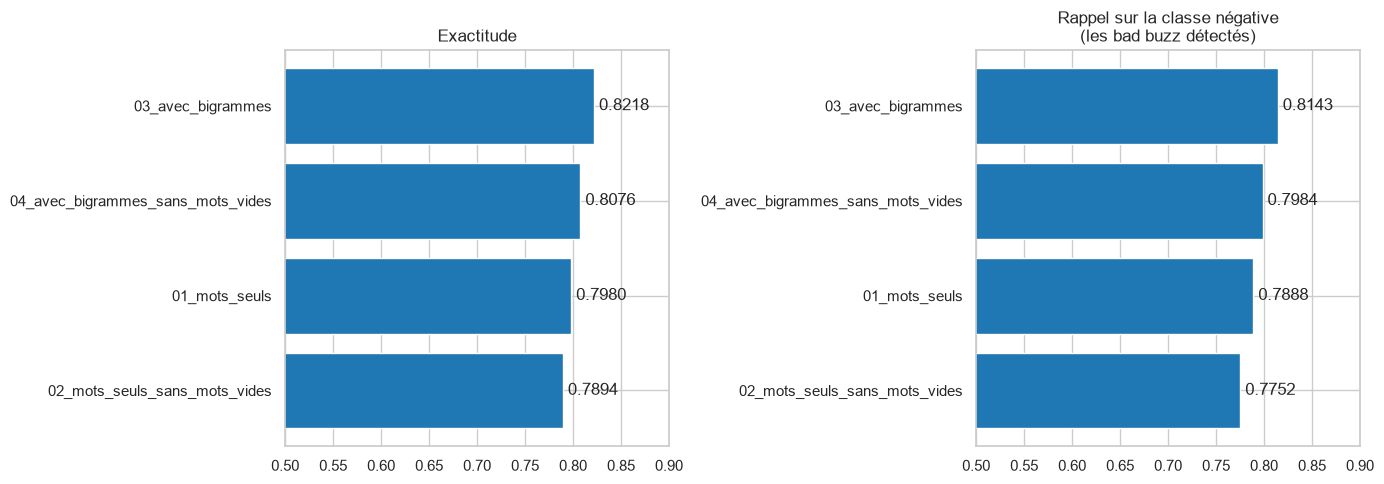

In [11]:
# Je regarde les deux mesures qui comptent : l'exactitude pour la vue
# d'ensemble, et le rappel sur la classe négative pour le besoin d'Air Paradis.
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for axe, (metrique, titre) in zip(axes, [
    ("exactitude", "Exactitude"),
    ("rappel_negatif", "Rappel sur la classe négative\n(les bad buzz détectés)"),
]):
    donnees_graphique = tableau.sort_values(metrique)
    axe.barh(donnees_graphique["configuration"], donnees_graphique[metrique], color="#1f77b4")
    axe.set_title(titre)
    axe.set_xlim(0.5, max(0.9, donnees_graphique[metrique].max() + 0.03))
    for index, valeur in enumerate(donnees_graphique[metrique]):
        axe.text(valeur, index, f" {valeur:.4f}", va="center")

plt.tight_layout()
plt.show()

In [12]:
# Quelle configuration je retiens ? Celle qui a la meilleure AUC.
#
# Pourquoi l'AUC et pas l'exactitude ? Parce qu'elle ne dépend pas du seuil de
# décision fixé à 0,5. Elle mesure la qualité du classement produit par le
# modèle, indépendamment du réglage qu'on appliquera ensuite. Or Air Paradis
# voudra sans doute baisser ce seuil pour attraper plus de bad buzz, donc
# autant choisir le modèle qui reste le meilleur quel que soit ce réglage.
NOM_MEILLEURE_CONFIGURATION = tableau.iloc[0]["configuration"]
meilleur_pipeline = modeles_entraines[NOM_MEILLEURE_CONFIGURATION]

print(f"Configuration retenue : {NOM_MEILLEURE_CONFIGURATION}\n")
print(tableau.iloc[0].to_string())

Configuration retenue : 03_avec_bigrammes

configuration         03_avec_bigrammes
ngram_max                             2
mots_vides_retires                False
vocabulaire                      300000
duree_s                            53.6
exactitude                       0.8218
auc_roc                          0.9006
f1_macro                         0.8218
precision_negatif                0.8296
rappel_negatif                   0.8143
f1_negatif                       0.8219


## 7. Regarder le modèle retenu de plus près

In [13]:
# Je recalcule les prédictions du meilleur modèle, en réappliquant le même
# prétraitement que celui utilisé pour l'entraîner.
configuration_retenue = next(
    c for c in CONFIGURATIONS if c["nom"] == NOM_MEILLEURE_CONFIGURATION
)

if configuration_retenue["retirer_mots_vides"]:
    textes_test_final = X_test.apply(retirer_mots_vides)
else:
    textes_test_final = X_test

probabilites_finales = meilleur_pipeline.predict_proba(textes_test_final)[:, 1]
metriques_finales = calculer_metriques(y_test, probabilites_finales)

afficher_metriques(metriques_finales, f"Modele classique, {NOM_MEILLEURE_CONFIGURATION}")

MODELE CLASSIQUE, 03_AVEC_BIGRAMMES
  Exactitude                : 0.8218
  AUC ROC                   : 0.9006
  F1 macro                  : 0.8218
--------------------------------------------------------
  Classe NEGATIVE (les bad buzz a detecter)
    Precision               : 0.8296
    Rappel                  : 0.8143   <-- mesure metier
    F1                      : 0.8219


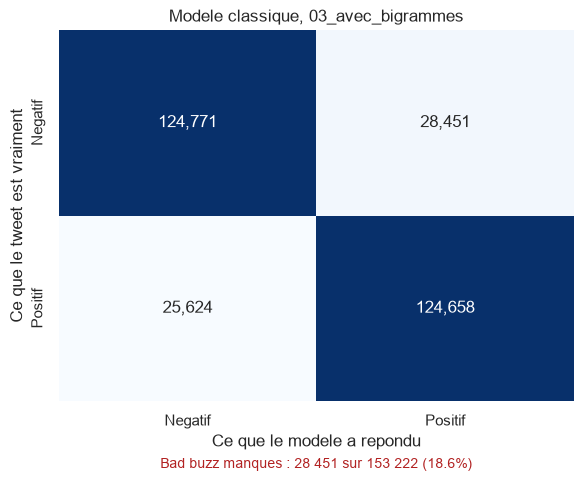

In [14]:
figure_matrice = tracer_matrice_confusion(
    y_test, probabilites_finales,
    titre=f"Modele classique, {NOM_MEILLEURE_CONFIGURATION}",
)
plt.show()

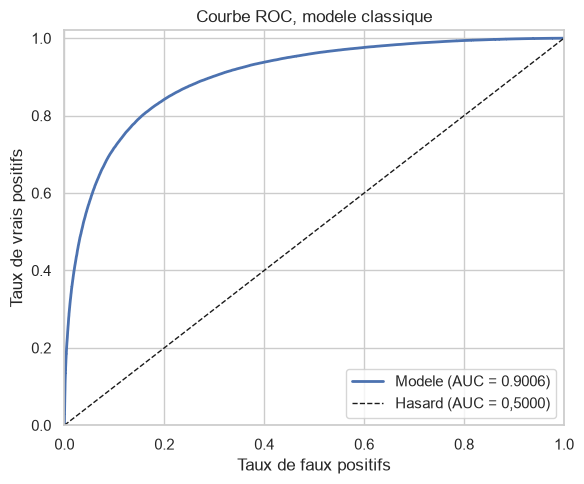

In [15]:
figure_roc = tracer_courbe_roc(
    y_test, probabilites_finales,
    titre="Courbe ROC, modele classique",
)
plt.show()

### Ce que le modèle a vraiment appris

La régression logistique attribue un poids à chaque terme du vocabulaire. Un
poids positif pousse vers la classe positive, un poids négatif vers la classe
négative.

C'est le gros avantage de cette approche : elle est directement
interprétable. Je peux ouvrir le modèle et lire mot par mot ce qu'il a retenu,
ce qui est impossible avec un réseau de neurones. Pour une présentation à une
audience non technique, c'est un argument précieux, et ça permet aussi de
repérer une bêtise, par exemple si le modèle s'était mis à s'appuyer sur un
mot sans rapport avec le sentiment.

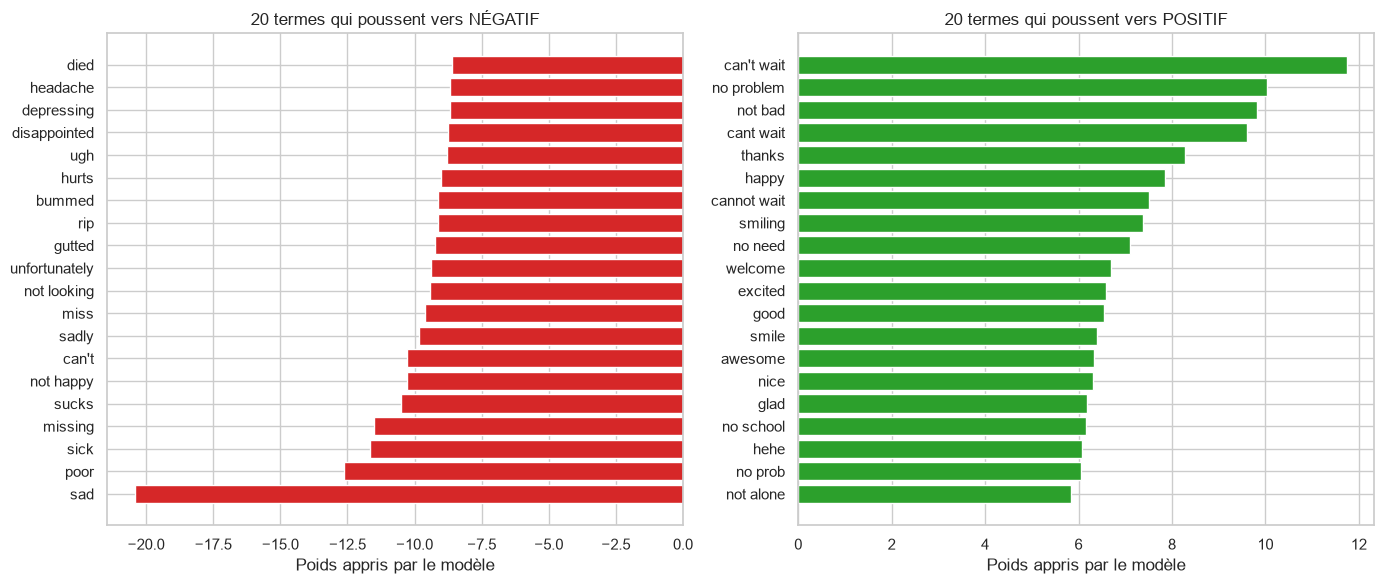

In [16]:
vectoriseur = meilleur_pipeline.named_steps["tfidf"]
classifieur = meilleur_pipeline.named_steps["classifieur"]

poids = pd.Series(classifieur.coef_[0], index=vectoriseur.get_feature_names_out())

figure, axes = plt.subplots(1, 2, figsize=(14, 6))

for axe, (selection, titre, couleur) in zip(axes, [
    (poids.nsmallest(20), "20 termes qui poussent vers NÉGATIF", "#d62728"),
    (poids.nlargest(20)[::-1], "20 termes qui poussent vers POSITIF", "#2ca02c"),
]):
    axe.barh(selection.index, selection.values, color=couleur)
    axe.set_title(titre)
    axe.set_xlabel("Poids appris par le modèle")

plt.tight_layout()
plt.show()

### Les erreurs du modèle

Les cas où le modèle se trompe en étant très sûr de lui sont les plus
instructifs, parce que ce sont eux qui montrent ses angles morts.

In [17]:
analyse = pd.DataFrame({
    "texte": donnees.loc[X_test.index, "texte"],
    "vrai_label": y_test,
    "probabilite_positif": probabilites_finales,
})
analyse["predit"] = (analyse["probabilite_positif"] >= 0.5).astype(int)
analyse["erreur"] = analyse["vrai_label"] != analyse["predit"]

# Les erreurs les plus confiantes : le modèle s'est trompé en étant très sûr.
erreurs = analyse[analyse["erreur"]].copy()
erreurs["confiance"] = (erreurs["probabilite_positif"] - 0.5).abs()

print("Tweets NÉGATIFS classés positifs avec le plus d'assurance.")
print("Ce sont les bad buzz qu'Air Paradis n'aurait pas vus venir.\n")
plus_graves = erreurs[erreurs["vrai_label"] == 0].nlargest(5, "confiance")
for _, ligne in plus_graves.iterrows():
    print(f"  probabilité d'être positif = {ligne['probabilite_positif']:.3f}")
    print(f"  {ligne['texte'].strip()[:150]}")
    print()

Tweets NÉGATIFS classés positifs avec le plus d'assurance.
Ce sont les bad buzz qu'Air Paradis n'aurait pas vus venir.

  probabilité d'être positif = 1.000
  @TataRita Thanks Ritou d'amour  &lt;3

  probabilité d'être positif = 1.000
  humf  thanks?

  probabilité d'être positif = 1.000
  @shercole Thanks Shercole

  probabilité d'être positif = 0.999
  @BeaMe101 good .....

  probabilité d'être positif = 0.998
  @BohemiaSkye Thanks Boz  x



## 8. Enregistrer le modèle dans MLflow

### Un problème rencontré, et comment je l'ai résolu

Mon premier essai d'enregistrement est resté bloqué 46 minutes sans rien
écrire, à 100 % d'un coeur de processeur. Ça vaut la peine d'expliquer
pourquoi, parce que c'est typiquement le genre de problème qu'on ne rencontre
jamais tant qu'on reste dans un notebook, et qui apparaît dès qu'on essaie de
mettre un modèle en production.

Pour trouver la cause, j'ai utilisé `faulthandler`, un module de la
bibliothèque standard qui affiche la pile d'appels d'un programme après un
délai donné. Autrement dit : il dit exactement à quelle ligne le programme est
en train de tourner. C'est bien plus efficace que de deviner.

Le verdict : depuis sa version 3, MLflow ne sauvegarde plus les modèles
scikit-learn avec `pickle`, mais avec `skops`. Skops est un format récent
conçu pour être sûr : charger un fichier pickle venant de l'extérieur permet
d'exécuter n'importe quel code sur la machine, et skops évite ce risque en
n'autorisant que des types connus.

Le problème, c'est que pour y arriver, skops parcourt l'objet élément par
élément, en Python pur. Mon vocabulaire TF-IDF contient 300 000 termes, donc
300 000 nœuds à visiter un par un. Le fichier ne fait pourtant que 13,5 Mo :
ce n'est pas un problème de taille, c'est un problème de nombre d'éléments.

Les mesures que j'ai faites :

| Format | Durée | Taille |
|---|---|---|
| `skops`, le défaut | plus de 46 min, jamais terminé | non mesurée |
| `cloudpickle` | 1,3 s | 13,5 Mo |
| `pickle` | 0,5 s | 13,5 Mo |

Je choisis `cloudpickle`. MLflow affiche un avertissement de sécurité quand on
le fait, et cet avertissement est justifié dans le cas général. Il ne
s'applique pas ici pour deux raisons : le modèle est produit par moi et stocké
sur ma propre machine, il ne vient d'aucune source extérieure, et surtout ce
n'est pas ce modèle-là qui partira en production. L'API servira le modèle
avancé, converti dans un format complètement différent.

### Verser le modèle au Model Registry

Le Model Registry est le catalogue central des modèles.

Le Model Registry est le catalogue central des modèles. Il apporte trois
choses qu'un simple fichier sauvegardé sur le disque n'apporte pas.

Un numéro de version, incrémenté à chaque enregistrement, donc je sais
toujours quelle version tourne où.

Une signature, c'est-à-dire la description de ce que le modèle attend en
entrée et de ce qu'il renvoie en sortie. Ça permet de détecter une
incompatibilité avant la mise en production plutôt qu'après.

Et le lien vers le run qui l'a produit, donc à tout moment je peux remonter
aux réglages et aux scores exacts de son entraînement.

C'est ce que le cahier des charges appelle la centralisation du stockage des
modèles.

In [18]:
with mlflow.start_run(run_name=f"modele_retenu_{NOM_MEILLEURE_CONFIGURATION}"):

    mlflow.log_params({
        "approche": "classique",
        "configuration_retenue": NOM_MEILLEURE_CONFIGURATION,
        "ngram_max": configuration_retenue["ngram_max"],
        "mots_vides_retires": configuration_retenue["retirer_mots_vides"],
        "nombre_tweets_entrainement": len(X_train),
    })
    mlflow.log_metrics(metriques_finales)

    # J'attache les graphiques au run, pour qu'ils restent consultables dans
    # l'interface MLflow à côté des scores correspondants, même une fois le
    # notebook fermé.
    mlflow.log_figure(figure_matrice, "matrice_confusion.png")
    mlflow.log_figure(figure_roc, "courbe_roc.png")

    # La signature est déduite d'un petit échantillon réel de tweets.
    #
    # Je passe un tableau numpy et pas une liste Python, et ce détail compte.
    # Mon modèle prend en entrée un tableau de textes à une dimension. Avec un
    # tableau numpy, MLflow enregistre la signature Tensor('str', (-1,)), qui
    # décrit exactement ça. Avec une liste Python, il enregistre "une colonne
    # de texte", ce qui ressemble à un tableau à deux dimensions, et le
    # rechargement générique du modèle échoue ensuite.
    #
    # J'ai vérifié les deux cas avant de choisir. La vérification est faite
    # juste après cette cellule.
    exemple_entree = np.array(textes_test_final.head(5))
    signature = infer_signature(exemple_entree, meilleur_pipeline.predict(exemple_entree))

    mlflow.sklearn.log_model(
        sk_model=meilleur_pipeline,
        name="modele",
        signature=signature,
        input_example=exemple_entree,
        # Sans cet argument, MLflow utilise le format skops par defaut et la
        # sauvegarde ne termine jamais sur un vocabulaire de 300 000 termes.
        # Voir l'explication juste au-dessus.
        serialization_format="cloudpickle",
        registered_model_name=f"{config.NOM_MODELE_ENREGISTRE}-classique",
    )

print("Modele enregistre dans le Model Registry.")
print(f"Consultable sur {config.URI_SUIVI_MLFLOW}, onglet Models")

2026/09/01 11:56:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully registered model 'analyse-sentiment-air-paradis-classique'.
2026/09/01 11:56:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: analyse-sentiment-air-paradis-classique, version 1


🏃 View run modele_retenu_03_avec_bigrammes at: http://127.0.0.1:5000/#/experiments/1/runs/81ceeac300904443a06db80702db127f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Modele enregistre dans le Model Registry.
Consultable sur http://127.0.0.1:5000, onglet Models


Created version '1' of model 'analyse-sentiment-air-paradis-classique'.


### Vérifier que le modèle est vraiment récupérable

Enregistrer un modèle ne sert à rien si on ne peut pas le ressortir. Je le
recharge donc depuis le Model Registry, sans passer par la variable que j'ai
en mémoire, et je vérifie qu'il prédit toujours la même chose.

C'est une vérification à faire systématiquement. C'est elle qui m'a fait
découvrir le problème de signature expliqué plus haut : le modèle
s'enregistrait sans erreur, mais refusait de se recharger.

Je teste les deux façons de le récupérer. La première rend l'objet
scikit-learn d'origine, avec toutes ses méthodes. La seconde passe par
l'interface générique de MLflow, celle qui serait utilisée par un serveur de
prédiction, et qui ne connaît rien à scikit-learn.

In [19]:
uri_modele = f"models:/{config.NOM_MODELE_ENREGISTRE}-classique/latest"

tweets_de_controle = np.array([
    "this flight was terrible, never again",
    "amazing crew, thank you so much",
    "not good at all",
])

# Facon 1 : je recupere l'objet scikit-learn d'origine.
modele_sklearn = mlflow.sklearn.load_model(uri_modele)
predictions_sklearn = modele_sklearn.predict(tweets_de_controle)

# Facon 2 : je passe par l'interface generique de MLflow.
modele_generique = mlflow.pyfunc.load_model(uri_modele)
predictions_generiques = modele_generique.predict(tweets_de_controle)

print("Tweet de controle                          sklearn  generique")
print("-" * 62)
for tweet, p1, p2 in zip(tweets_de_controle, predictions_sklearn, predictions_generiques):
    etiquette = "positif" if p1 == 1 else "negatif"
    print(f"{tweet[:40]:42s} {p1:^8d} {p2:^9d}  -> {etiquette}")

print("\nLes deux facons donnent le meme resultat :",
      list(predictions_sklearn) == list(predictions_generiques))

Tweet de controle                          sklearn  generique
--------------------------------------------------------------
this flight was terrible, never again         0         0      -> negatif
amazing crew, thank you so much               1         1      -> positif
not good at all                               0         0      -> negatif

Les deux facons donnent le meme resultat : True


## Conclusion

### Ce que fait ce modèle

Il transforme chaque tweet en une liste de fréquences pondérées avec TF-IDF,
puis il apprend un poids par terme avec une régression logistique. Il
s'entraîne en quelques minutes sur un processeur ordinaire, sur l'intégralité
du million et demi de tweets.

### Ses points forts

Il est rapide : l'entraînement se compte en minutes, la prédiction en
microsecondes.

Il est interprétable : je peux lire mot par mot ce qu'il a appris. Pour une
présentation destinée à une audience non technique, c'est un vrai atout.

Il est léger : quelques dizaines de mégaoctets, aucune contrainte de
déploiement.

### Sa limite, mesurée et pas supposée

Il ignore l'ordre des mots. Les bigrammes atténuent le problème pour les mots
collés l'un à l'autre, mais ne le résolvent pas : une négation éloignée de son
adjectif lui échappe complètement.

C'est exactement ce plafond que l'approche suivante va essayer de franchir,
avec des modèles qui lisent le tweet comme une phrase plutôt que comme un sac.

Étape suivante : `03_modele_avance.ipynb`